In [41]:
import pandas as pd
import numpy as np
import joblib
import os

# Load v3 features (74 engineered + 8 BG/NBD = 82 features)
features = pd.read_csv("../data/customer_features_v3.csv")
test     = pd.read_csv("../data/customer_clv_test.csv")

test_df = test.merge(features, on="cust_id", how="left")
print(f"Test customers: {len(test_df)}")
print(f"Missing values: {test_df.isna().any(axis=1).sum()}")
test_df = test_df.fillna(0)


Test customers: 29148
Missing values: 0


In [42]:
# Load ML models and ensemble config
feature_cols_ml   = joblib.load("../models/feature_cols_ml.pkl")
ensemble_weights  = joblib.load("../models/ml_ensemble_weights.pkl")
alpha_opt         = joblib.load("../models/blend_alpha.pkl")
USE_BLEND         = joblib.load("../models/use_blend.pkl")
USE_SOFT_SCALING  = joblib.load("../models/use_soft_scaling.pkl")

w_lgb = ensemble_weights["w_lgb"]
w_xgb = ensemble_weights["w_xgb"]
w_cat = ensemble_weights["w_cat"]

# Single-stage models (trained on all customers)
ml_lgb = joblib.load("../models/ml_lgb_model.pkl")
ml_xgb = joblib.load("../models/ml_xgb_model.pkl")
ml_cat = joblib.load("../models/ml_cat_model.pkl")

# Conditional models (trained on returning customers only)
cond_lgb = joblib.load("../models/cond_lgb_model.pkl")
cond_xgb = joblib.load("../models/cond_xgb_model.pkl")
cond_cat = joblib.load("../models/cond_cat_model.pkl")

print(f"Ensemble weights: LGB={w_lgb:.3f}  XGB={w_xgb:.3f}  CAT={w_cat:.3f}")
print(f"BG/NBD blend alpha: {alpha_opt:.4f}")
print(f"USE_BLEND={USE_BLEND}  USE_SOFT_SCALING={USE_SOFT_SCALING}")


Ensemble weights: LGB=0.217  XGB=0.449  CAT=0.333
BG/NBD blend alpha: 0.0000
USE_BLEND=True  USE_SOFT_SCALING=False


In [43]:
X_test = test_df[feature_cols_ml].values

# Single-stage ML ensemble
test_pred_lgb = np.expm1(ml_lgb.predict(X_test)).clip(0)
test_pred_xgb = np.expm1(ml_xgb.predict(X_test)).clip(0)
test_pred_cat = np.expm1(ml_cat.predict(X_test)).clip(0)
test_pred_ml  = w_lgb * test_pred_lgb + w_xgb * test_pred_xgb + w_cat * test_pred_cat

# BG/NBD standalone
bgnbd_test    = test_df["bgnbd_clv"].fillna(0).clip(0).values
p_alive_test  = test_df["p_alive"].fillna(0).clip(0).values

# Soft scaling: p_alive × conditional revenue
cond_log_test  = (cond_lgb.predict(X_test) +
                  cond_xgb.predict(X_test) +
                  cond_cat.predict(X_test)) / 3
test_pred_soft = p_alive_test * np.expm1(cond_log_test).clip(0)

# Select best strategy based on OOF results from notebook 04
if USE_SOFT_SCALING:
    final_pred = test_pred_soft
    strategy   = "soft_scaling"
elif USE_BLEND:
    final_pred = alpha_opt * bgnbd_test + (1 - alpha_opt) * test_pred_ml
    strategy   = "bgnbd_blend"
else:
    final_pred = test_pred_ml
    strategy   = "ml_ensemble"

final_pred = final_pred.clip(0)
print(f"Strategy: {strategy}")
print(f"Predictions  min={final_pred.min():.2f}  median={np.median(final_pred):.2f}  max={final_pred.max():.2f}")
print(f"Zero predictions: {(final_pred == 0).sum()} / {len(final_pred)}")


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Strategy: bgnbd_blend
Predictions  min=0.00  median=0.00  max=561.72
Zero predictions: 3723 / 29148


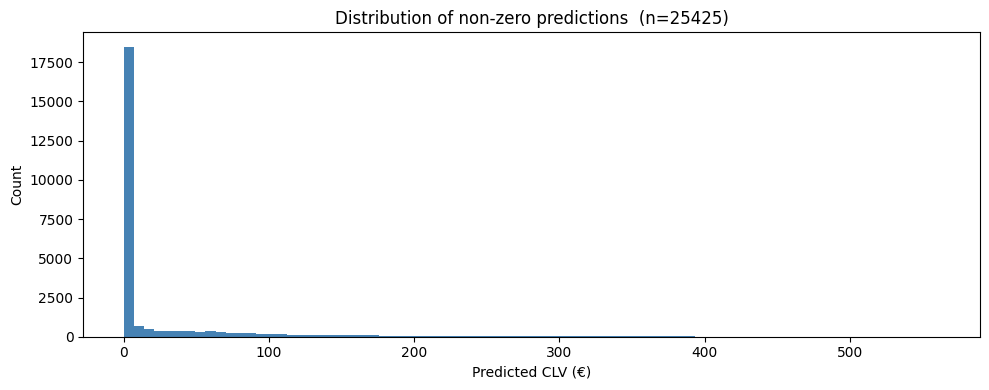


Prediction statistics:
count    2.914800e+04
mean     2.462649e+01
std      6.466341e+01
min      0.000000e+00
25%      2.019417e-08
50%      1.538217e-03
75%      4.697602e+00
max      5.617169e+02
dtype: float64


In [44]:
import matplotlib.pyplot as plt

# Prediction distribution
plt.figure(figsize=(10, 4))
plt.hist(final_pred[final_pred > 0], bins=80, edgecolor="none", color="steelblue")
plt.xlabel("Predicted CLV (€)")
plt.ylabel("Count")
plt.title(f"Distribution of non-zero predictions  (n={( final_pred > 0).sum()})")
plt.tight_layout()
plt.show()

print(f"\nPrediction statistics:")
print(pd.Series(final_pred).describe())


In [45]:
os.makedirs("../submissions", exist_ok=True)

submission = pd.DataFrame({
    "cust_id":    test_df["cust_id"],
    "prediction": final_pred
})

fname = f"../submissions/submission_v7_{strategy}.csv"
submission.to_csv(fname, index=False)
print(f"Saved {len(submission)} predictions → {fname}")
print(submission["prediction"].describe())


Saved 29148 predictions → ../submissions/submission_v7_bgnbd_blend.csv
count    2.914800e+04
mean     2.462649e+01
std      6.466341e+01
min      0.000000e+00
25%      2.019417e-08
50%      1.538217e-03
75%      4.697602e+00
max      5.617169e+02
Name: prediction, dtype: float64
